In [13]:
import pandas as pd
from collections import Counter
import re

# Define positive and negative word lists
positive_words = ['beautiful', 'fast', 'great', 'good', 'gorgeous', 'fantastic', 'lovely', 'wonderful', 'happy', 'prompt', 'excellent', 'exquisite', 'fabulous', 'efficient', 'amazing', 'perfect', 'stunning', 'brilliant']
negative_words = ['damaged', 'slow', 'broken', 'delayed', 'poor', 'faulty', 'difficult']

# Function to get counts
def get_word_counts(filepath):
    df = pd.read_csv(filepath)
    all_text = " ".join(df['Body'].dropna().astype(str))
    all_text = re.sub(r'[^\w\s]', '', all_text.lower())
    words = all_text.split()
    word_counts = Counter(words)
    
    positive_counts = {word: word_counts[word] for word in positive_words}
    negative_counts = {word: word_counts[word] for word in negative_words}
    
    return positive_counts, negative_counts

# Get counts for each company
mrs_alice_pos, mrs_alice_neg = get_word_counts('../data/raw/trustpilot_reviews_mrsalice.csv')
abask_pos, abask_neg = get_word_counts('../data/raw/trustpilot_reviews_abask.csv')
rebecca_pos, rebecca_neg = get_word_counts('../data/raw/trustpilot_reviews_rebecca_udall.csv')


print('Mrs Alice Positive:', mrs_alice_pos)
print('Mrs Alice Negative:', mrs_alice_neg)
print('Abask Positive:', abask_pos)
print('Abask Negative:', abask_neg)
print('Rebecca Udall Positive:', rebecca_pos)
print('Rebecca Udall:', rebecca_neg)

Mrs Alice Positive: {'beautiful': 348, 'fast': 137, 'great': 190, 'good': 97, 'gorgeous': 66, 'fantastic': 18, 'lovely': 144, 'wonderful': 60, 'happy': 60, 'prompt': 41, 'excellent': 96, 'exquisite': 12, 'fabulous': 30, 'efficient': 34, 'amazing': 52, 'perfect': 60, 'stunning': 42, 'brilliant': 8}
Mrs Alice Negative: {'damaged': 17, 'slow': 5, 'broken': 15, 'delayed': 9, 'poor': 13, 'faulty': 3, 'difficult': 4}
Abask Positive: {'beautiful': 82, 'fast': 36, 'great': 55, 'good': 15, 'gorgeous': 11, 'fantastic': 11, 'lovely': 13, 'wonderful': 18, 'happy': 6, 'prompt': 10, 'excellent': 40, 'exquisite': 8, 'fabulous': 2, 'efficient': 13, 'amazing': 18, 'perfect': 26, 'stunning': 7, 'brilliant': 2}
Abask Negative: {'damaged': 1, 'slow': 0, 'broken': 3, 'delayed': 2, 'poor': 0, 'faulty': 0, 'difficult': 1}
Rebecca Udall Positive: {'beautiful': 83, 'fast': 15, 'great': 48, 'good': 22, 'gorgeous': 24, 'fantastic': 16, 'lovely': 38, 'wonderful': 17, 'happy': 10, 'prompt': 8, 'excellent': 46, 'ex

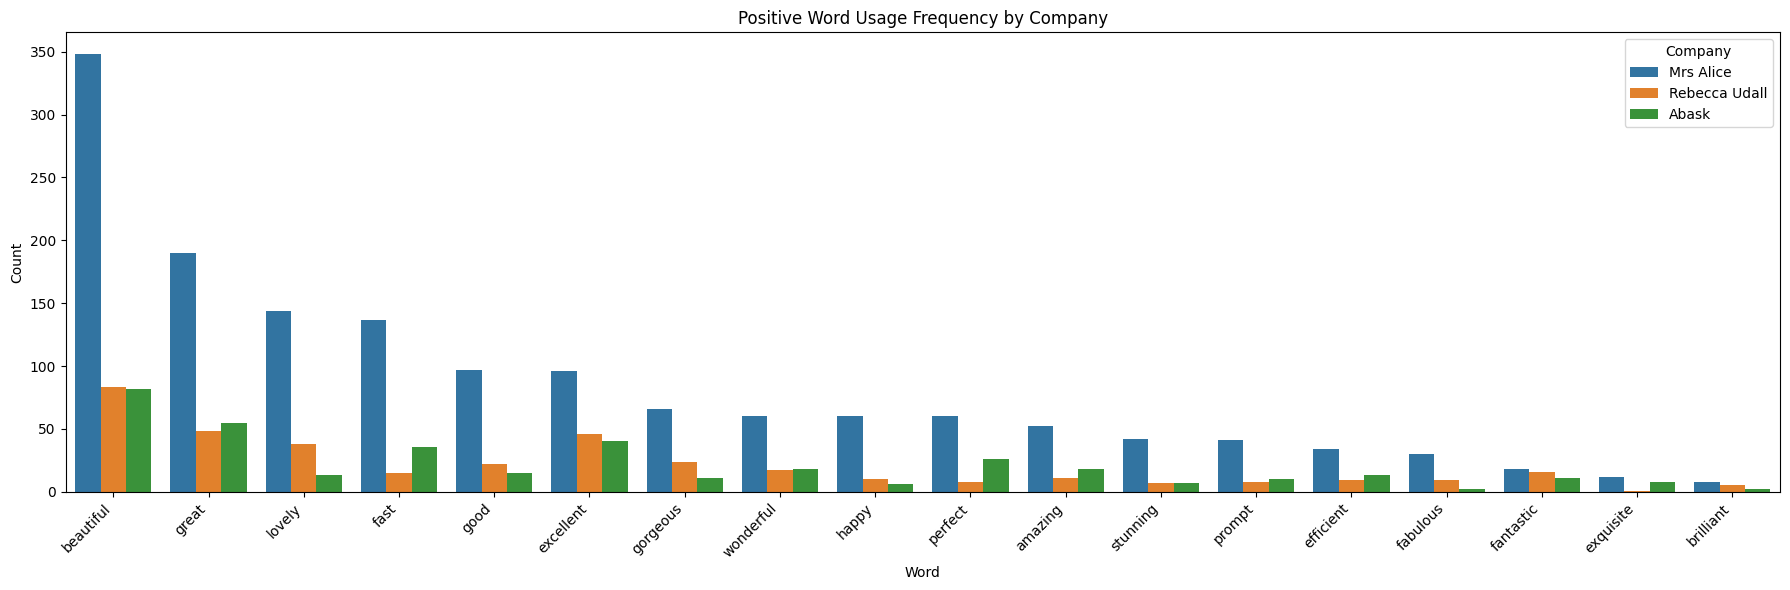

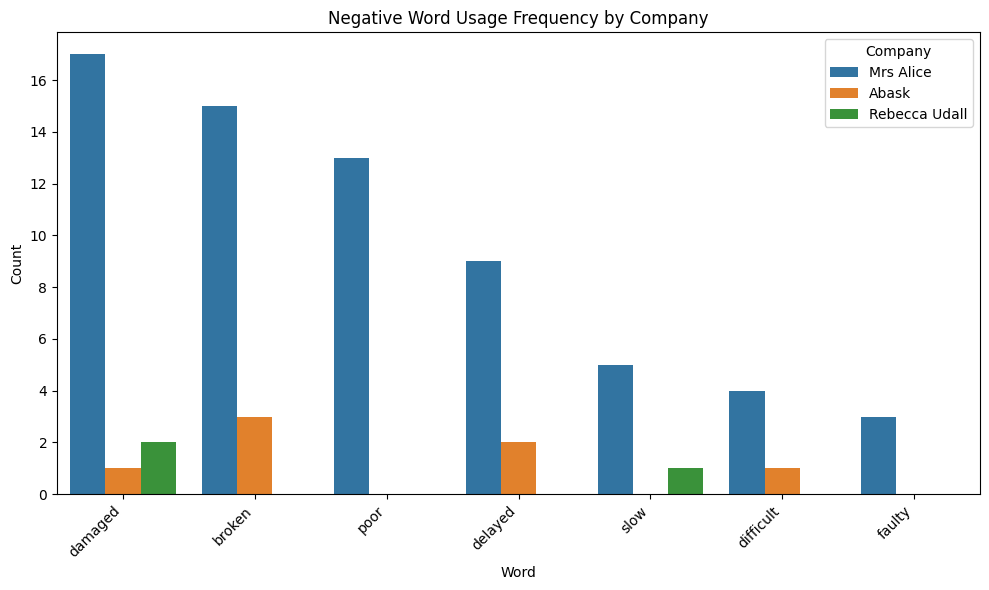

In [ ]:
# Prepare positive word data
positive_data = []
for word in positive_words:
    positive_data.append({'Word': word, 'Company': 'Mrs Alice', 'Count': mrs_alice_pos.get(word, 0)})
    positive_data.append({'Word': word, 'Company': 'Abask', 'Count': abask_pos.get(word, 0)})
    positive_data.append({'Word': word, 'Company': 'Rebecca Udall', 'Count': rebecca_pos.get(word, 0)})

# Prepare negative word data
negative_data = []
for word in negative_words:
    negative_data.append({'Word': word, 'Company': 'Mrs Alice', 'Count': mrs_alice_neg.get(word, 0)})
    negative_data.append({'Word': word, 'Company': 'Abask', 'Count': abask_neg.get(word, 0)})
    negative_data.append({'Word': word, 'Company': 'Rebecca Udall', 'Count': rebecca_neg.get(word, 0)})

# Create DataFrames
df_positive = pd.DataFrame(positive_data)
df_negative = pd.DataFrame(negative_data)

# Sort the DataFrame by Mrs Alice counts
df_positive_sorted = df_positive.sort_values(by='Count', ascending=False)
df_negative_sorted = df_negative.sort_values(by='Count', ascending=False)


import matplotlib.pyplot as plt
import seaborn as sns

# Plot Positive Words
plt.figure(figsize=(18, 6))
sns.barplot(df_positive_sorted, x='Word', y='Count', hue='Company')
plt.title('Positive Word Usage Frequency by Company')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Company')
plt.tight_layout()
plt.show()

# Plot Negative Words
plt.figure(figsize=(10, 6))
sns.barplot(data=df_negative_sorted, x='Word', y='Count', hue='Company')
plt.title('Negative Word Usage Frequency by Company')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Company')
plt.tight_layout()
plt.show()



In [19]:
# Calculate total positive and negative counts for each company
positive_totals = df_positive.groupby('Company')['Count'].sum()
negative_totals = df_negative.groupby('Company')['Count'].sum()

# Combine the results into one DataFrame
review_totals = pd.DataFrame({
    'Total Positive Reviews': positive_totals,
    'Total Negative Reviews': negative_totals
})

# Calculate the ratio of positive to negative reviews for each company
review_totals['Pos to Neg Ratio'] = review_totals['Total Positive Reviews'] / review_totals['Total Negative Reviews']

# Display the updated DataFrame
print(review_totals)


               Total Positive Reviews  Total Negative Reviews  \
Company                                                         
Abask                             373                       7   
Mrs Alice                        1495                      66   
Rebecca Udall                     377                       3   

               Pos to Neg Ratio  
Company                          
Abask                 53.285714  
Mrs Alice             22.651515  
Rebecca Udall        125.666667  
